# alphadia-validate
A notebook for exploring DIA hits for the sake of validation.

In [1]:
%reload_ext autoreload
%autoreload 2

In [ ]:
import os

from pathlib import Path
from src.slicer import SpectrumSlicer

from src.isoform_attention import isoform_attention_plot
from src.io import load_alphadia_data, EXAMPLE_RAW_DATA_URL, EXAMPLE_PRECURSORS_TSV_URL, EXAMPLE_SPECLIB_URL
from src.mirror_plotting import mirror_with_xic_and_corrs_for_hash

from IPython.display import Image

## 0. Set up data

In [3]:
# this is the folder where the data should be read from / downloaded to
custom_folder = "~//alphadia-validate"

# either download example data ..
download_data = True

# .. or use your own data
# download_data = False
raw_file_name = "20231017_OA2_TiHe_ADIAMA_HeLa_200ng_Evo011_21min_F-40_07.mzML" # raw file
precursors_file_name = "precursors.tsv" # output of an AlphaDIA search (cf. search.ipynb)
speclib_file_name = "speclib.hdf" # output of an AlphaDIA search (cf. search.ipynb)

In [6]:


main_folder = Path(os.environ.get("BASE_FOLDER", custom_folder)).expanduser()

if download_data:
    precursor_df, spectral_library, spectral_library_flat, dia_data = load_alphadia_data(
        main_folder, download_urls=(EXAMPLE_RAW_DATA_URL, EXAMPLE_PRECURSORS_TSV_URL, EXAMPLE_SPECLIB_URL)
    )
else:
    precursor_df, spectral_library, spectral_library_flat, dia_data = load_alphadia_data(
    main_folder,
    raw_file_name = raw_file_name,
    precursors_file_name = precursors_file_name,
    speclib_file_name = speclib_file_name
)


/Users/mschwoerer/alphadia-validate/20231017_OA2_TiHe_ADIAMA_HeLa_200ng_Evo011_21min_F-40_07.mzML already exists (2837.022081375122 MB)
/Users/mschwoerer/alphadia-validate/precursors.tsv already exists (80.31055164337158 MB)
/Users/mschwoerer/alphadia-validate/speclib.hdf already exists (124.88468170166016 MB)
Reading raw file ...
Parsing spectral library ...


## 1. Select a precursor

In [14]:
# user input: select via position
selected_hash = precursor_df["mod_seq_charge_hash"].iloc[3000]

# alternatively: select via sequence
#selected_hash = precursor_df[sequence == "SOME_SEQUENCE"]

# alternatively: use a random one from a certain percentile
# from src.small_helpers import get_random_precursor_hash
# selected_hash = get_random_precursor_hash(precursor_df, 0)

## 2. Preprocess

In [ ]:
slicer = SpectrumSlicer(spectral_library_flat, precursor_df, dia_data)

## 3. Plots

### Mirror plots


In [ ]:
mirror_with_xic_and_corrs_for_hash(
    slicer,
    selected_hash,
    width=500,
    height=300,
)

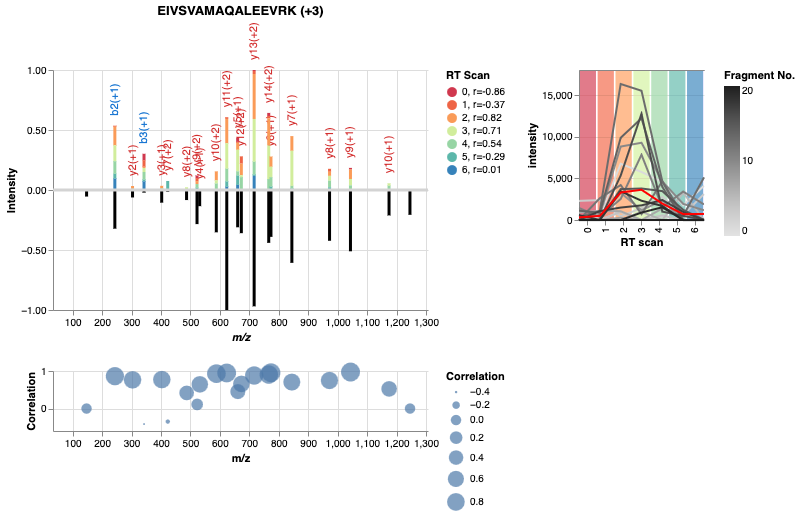

In [10]:
# this is just for display on GitHub as it does not show altair plots
Image(filename="../misc/mirror.png")

### Isoform attention plot

sequence     EIVSVAMAQALEEVRK
mods                         
mod_sites                    
Name: 3000, dtype: object


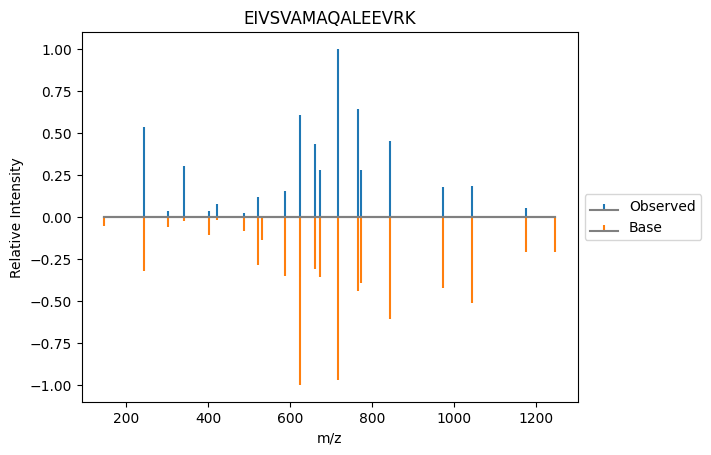

In [16]:
# in case you want to find some precursors with modifications:
# display(precursor_df[~pd.isna(precursor_df["mods"])][["mod_seq_charge_hash", "mods"]].head(10))

isoform_attention_plot(spectral_library_flat, precursor_df, dia_data, selected_hash)

### Shared fragments
In order to play with that plot, use the `shared_fragment_histogram.ipynb` notebook.

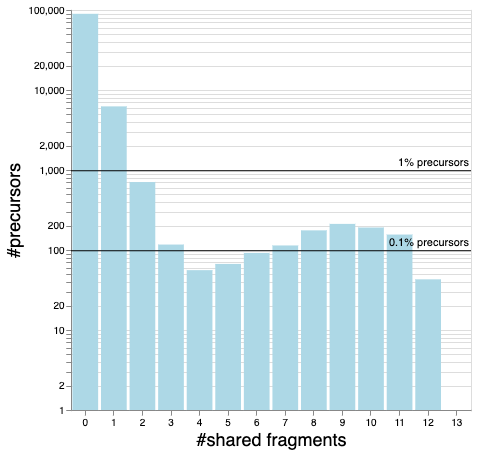

In [13]:
Image(filename="../misc/shared_fragment_histogram.png")